**Exploratory Data Analysis**
Using cleaned csv files
This notebook explores the cleaned OASIS-1 and OASIS-2 datasets,
focusing on demographic characteristics, cognitive scores and
normalised whole brain volume (nWBV)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
oasis1 = pd.read_csv("oasis1_snapshot.csv")
oasis2 = pd.read_csv("oasis2_longitudinal.csv")

In [3]:
oasis1.shape

(198, 13)

In [4]:
oasis2.shape

(373, 13)

In [5]:
oasis1.info()

<class 'pandas.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      198 non-null    str    
 1   group           198 non-null    str    
 2   visit           198 non-null    int64  
 3   mr_delay        198 non-null    int64  
 4   gender          198 non-null    str    
 5   age             198 non-null    int64  
 6   education       198 non-null    int64  
 7   ses             198 non-null    int64  
 8   mmse            198 non-null    float64
 9   cdr             198 non-null    float64
 10  etiv            198 non-null    int64  
 11  nwbv            198 non-null    float64
 12  dataset_source  198 non-null    str    
dtypes: float64(3), int64(6), str(4)
memory usage: 20.2 KB


In [6]:
oasis2.info()

<class 'pandas.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      373 non-null    str    
 1   group           373 non-null    str    
 2   visit           373 non-null    int64  
 3   mr_delay        373 non-null    int64  
 4   gender          373 non-null    str    
 5   age             373 non-null    int64  
 6   education       373 non-null    int64  
 7   ses             373 non-null    int64  
 8   mmse            373 non-null    float64
 9   cdr             373 non-null    float64
 10  etiv            373 non-null    float64
 11  nwbv            373 non-null    float64
 12  dataset_source  373 non-null    str    
dtypes: float64(4), int64(5), str(4)
memory usage: 38.0 KB


In [7]:
oasis1.isnull().sum()

patient_id        0
group             0
visit             0
mr_delay          0
gender            0
age               0
education         0
ses               0
mmse              0
cdr               0
etiv              0
nwbv              0
dataset_source    0
dtype: int64

In [8]:
oasis2.isnull().sum()

patient_id        0
group             0
visit             0
mr_delay          0
gender            0
age               0
education         0
ses               0
mmse              0
cdr               0
etiv              0
nwbv              0
dataset_source    0
dtype: int64

In [9]:
oasis1.duplicated().sum()

np.int64(0)

In [10]:
oasis2.duplicated().sum()

np.int64(0)

In [11]:
oasis1.describe()

,visit,mr_delay,age,education,ses,mmse,cdr,etiv,nwbv
count,198.0,198.0,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000,198.000000
mean,1.0,0.0,76.343434,3.040404,2.656566,26.616162,0.338384,1461.525253,0.737091
std,0.0,0.0,8.087292,1.320815,1.082032,3.853160,0.395587,160.772996,0.041595
min,1.0,0.0,60.000000,1.000000,1.000000,14.000000,0.000000,1123.000000,0.644000
25%,1.0,0.0,71.000000,2.000000,2.000000,25.250000,0.000000,1350.000000,0.705250
50%,1.0,0.0,75.500000,3.000000,3.000000,28.000000,0.500000,1451.000000,0.738500
75%,1.0,0.0,82.000000,4.000000,4.000000,29.000000,0.500000,1544.250000,0.766000
max,1.0,0.0,96.000000,5.000000,5.000000,30.000000,2.000000,1992.000000,0.839000


In [12]:
oasis2.describe()

,visit,mr_delay,age,education,ses,mmse,cdr,etiv,nwbv
count,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000,373.000000
mean,1.882038,595.104558,77.013405,14.597855,2.436997,27.309651,0.290885,1488.121584,0.729556
std,0.922843,635.485118,7.640957,2.876339,1.109307,3.700656,0.374557,176.135956,0.037141
min,1.000000,0.000000,60.000000,6.000000,1.000000,4.000000,0.000000,1105.652499,0.644399
25%,1.000000,0.000000,71.000000,12.000000,2.000000,27.000000,0.000000,1357.330000,0.700191
50%,2.000000,552.000000,77.000000,15.000000,2.000000,29.000000,0.000000,1470.041312,0.728789
75%,2.000000,873.000000,82.000000,16.000000,3.000000,30.000000,0.500000,1596.936793,0.755669
max,5.000000,2639.000000,98.000000,23.000000,5.000000,30.000000,2.000000,2004.479526,0.836842


OASIS 1
People in each group 

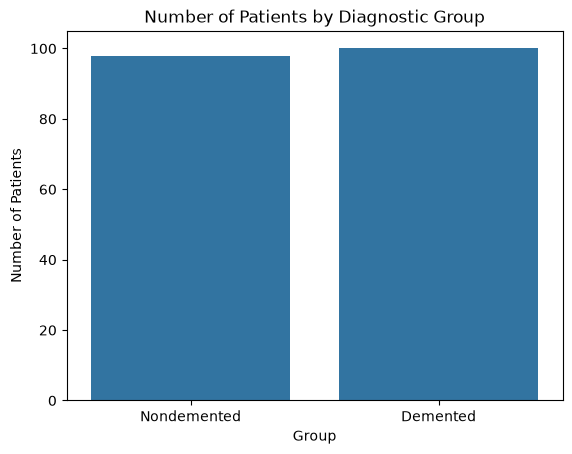

In [13]:
sns.countplot(data=oasis1, x="group")
plt.title("Number of Patients by Diagnostic Group")
plt.xlabel("Group")
plt.ylabel("Number of Patients")
plt.show()

The OASIS-1 dataset contains a similar number of nondemented and demented participants. This relatively balanced group distribution allows the two diagnostic groups to be compared without a large difference in sample size.

Distribution of brain volume

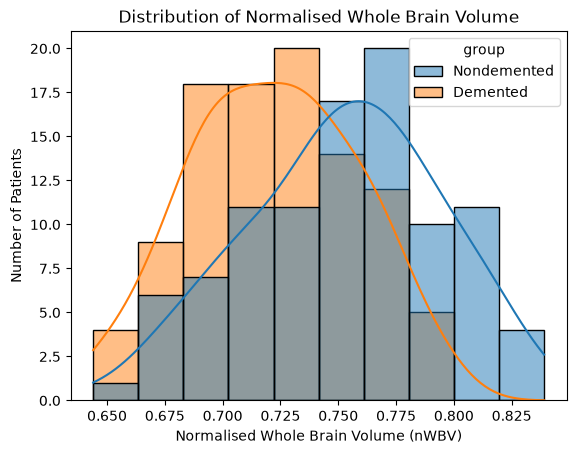

In [14]:
sns.histplot(
    data=oasis1,
    x="nwbv",
    hue="group",
    kde=True)
plt.title("Distribution of Normalised Whole Brain Volume")
plt.xlabel("Normalised Whole Brain Volume (nWBV)")
plt.ylabel("Number of Patients")
plt.show()

The distribution of nWBV appears shifted towards lower values in the demented group compared with the nondemented group. Although there is considerable overlap between the groups, nondemented participants generally show higher brain volume measurements.

Brain volume by dementia status

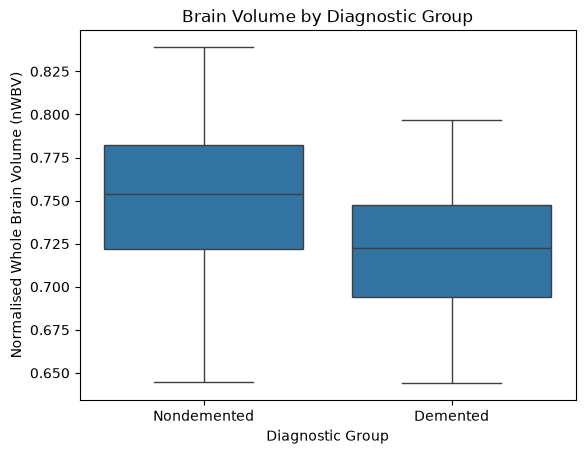

In [15]:
sns.boxplot(
    data=oasis1,
    x="group",
    y="nwbv")
plt.title("Brain Volume by Diagnostic Group")
plt.xlabel("Diagnostic Group")
plt.ylabel("Normalised Whole Brain Volume (nWBV)")
plt.show()

The median normalised whole brain volume is lower in the demented group than in the nondemented group. However, the distributions overlap, showing that brain volume varies considerably between individuals and is not sufficient on its own to distinguish the two groups.

AGE vs Brain Volume

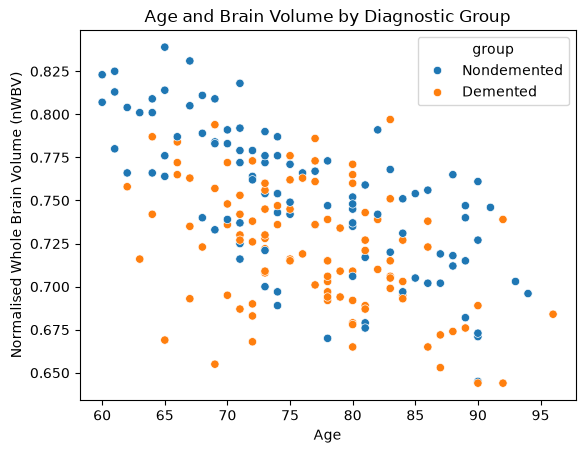

In [16]:
sns.scatterplot(
    data=oasis1,
    x="age",
    y="nwbv",
    hue="group")
plt.title("Age and Brain Volume by Diagnostic Group")
plt.xlabel("Age")
plt.ylabel("Normalised Whole Brain Volume (nWBV)")
plt.show()

Normalised whole brain volume generally appears to decrease with increasing age in both diagnostic groups. Across much of the age range, demented participants also tend to have lower nWBV values than nondemented participants, although there is substantial overlap between the groups.

MMSE vs Dementia Status

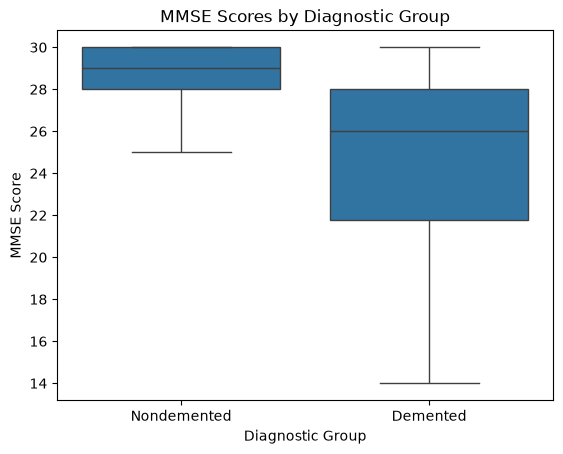

In [17]:
sns.boxplot(
    data=oasis1,
    x="group",
    y="mmse")
plt.title("MMSE Scores by Diagnostic Group")
plt.xlabel("Diagnostic Group")
plt.ylabel("MMSE Score")
plt.show()

Nondemented participants generally have higher MMSE scores, with scores concentrated near the upper end of the scale. The demented group has a lower median MMSE score and a wider range of scores, indicating greater variation in cognitive performance.

OASIS 2

In [18]:
oasis2["group"].value_counts()

group
Nondemented    190
Demented       146
Converted       37
Name: count, dtype: int64

Brain Volume by Group

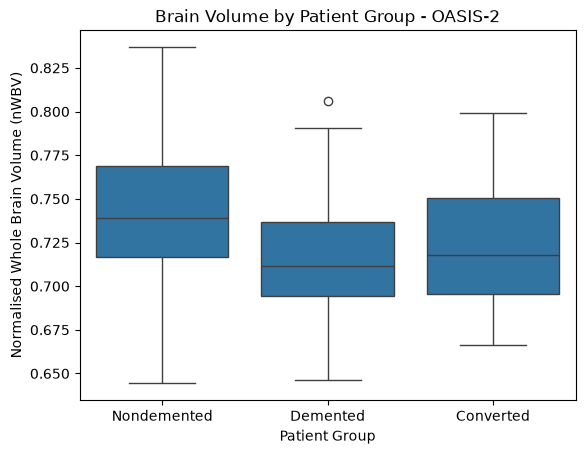

In [19]:
sns.boxplot(
    data=oasis2,
    x="group",
    y="nwbv")
plt.title("Brain Volume by Patient Group - OASIS-2")
plt.xlabel("Patient Group")
plt.ylabel("Normalised Whole Brain Volume (nWBV)")
plt.show()

Brain volume measurements are generally highest in the nondemented group and lower in the demented and converted groups. The converted group shows values between the other two groups, although there is substantial overlap across all three groups.

Brain volume through Visits

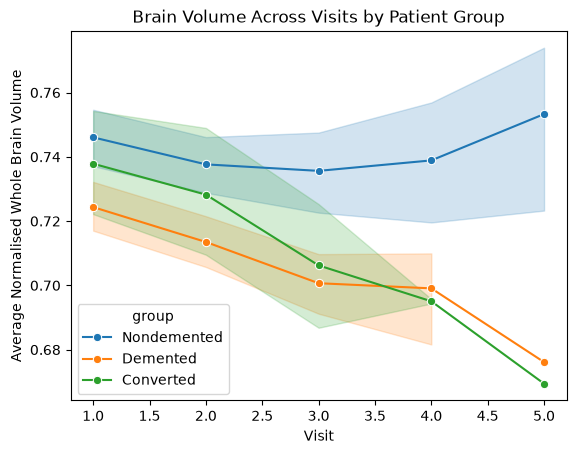

In [20]:
sns.lineplot(
    data=oasis2,
    x="visit",
    y="nwbv",
    hue="group",
    marker="o")
plt.title("Brain Volume Across Visits by Patient Group")
plt.xlabel("Visit")
plt.ylabel("Average Normalised Whole Brain Volume")
plt.show()

Average nWBV decreases across visits in the demented and converted groups, with the converted group showing a particularly pronounced decline at later visits. In contrast, the nondemented group remains relatively stable across the earlier visits. These patterns suggest that longitudinal change in brain volume may provide more information than a single measurement.

**EDA Summary**

Exploratory analysis shows that demented participants generally have lower normalised whole brain volume and lower MMSE scores than nondemented participants. Brain volume also appears to decrease with age. In the OASIS-2 data, demented and converted participants show greater reductions in average nWBV across visits, supporting further investigation of brain volume change over time rather than relying only on cross-sectional measurements.